# CP3 — Model Training & Evaluation
**Thesis:** Predicting F1 Race Finishing Positions (2022–2025 ground-effect era), ensemble ML + SHAP.

Checkpoint 3 of 5. Trains **Random Forest** and **XGBoost** regressors on 2022–2024, evaluates on the
held-out **2025** season against naive baselines, and selects the model to carry into CP4 (SHAP).
**No SHAP here (CP4). No model export here (CP5).**

### Decisions / deviations from the base spec (verified against our CP2 outputs)
- **Encoding already done in CP2.** `driver_encoded`/`team_encoded` are integer columns in the CSVs,
  so there is no re-encoding (and no `LabelEncoder` crash). The real issue is **3 rookie driver codes
  unseen in training (ANT, BOR, HAD)** → remapped to the **median training driver code** (the spec's
  "simplest safe approach"). Teams have no unseen codes.
- **Smarter NaN imputation.** `constructor_season_points` NaN = a team's *first race of a season* =
  genuinely **0 points**, so it is filled with **0** (median would falsely inflate it to ~39). All
  other rolling/pace NaNs use **train-median** (median ≫ 0 for position features, which live in 1–20).
- **CV grouping** uses a combined **`(season,round)` race id** (68 real races) instead of bare `round`
  (which repeats across seasons) — each race stays wholly inside one fold; imputation runs *inside* the
  CV pipeline (per-fold, no leakage).
- Accuracy buckets use **rounded** predictions; MAE/R²/Spearman use **raw floats** (per the rules).

## Setup

In [34]:
from pathlib import Path
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             make_scorer)
from scipy.stats import spearmanr
from xgboost import XGBRegressor

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"; MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / "reports" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
                     "axes.titleweight": "bold"})
saved_figures = []
def save_fig(fig, name):
    fig.savefig(FIG_DIR / name); saved_figures.append(name)
    print("  saved ->", f"reports/figures/{name}")

train_df = pd.read_csv(PROC / "train.csv")
test_df = pd.read_csv(PROC / "test.csv")
FEATURES = json.load(open(MODELS_DIR / "feature_list.json"))
TARGET = "final_position"
print("Train:", train_df.shape, "| Test:", test_df.shape, "| Features:", len(FEATURES))
print("XGBoost will be used (loaded OK).")
train_df.head(3)

Train: (1350, 43) | Test: (476, 43) | Features: 24
XGBoost will be used (loaded OK).


,season,round,driver,event_name,country,location,date,is_street_circuit,total_race_laps,driver_number,...,clean_pace_delta,teammate_pace_delta,driver_rolling_avg_3,driver_rolling_avg_5,driver_dnf_rate_season,constructor_rolling_avg_points_3,constructor_season_points,compound_encoded,team_encoded,driver_encoded
0,2022,1,ALB,Bahrain Grand Prix,Bahrain,Sakhir,2022-03-20,False,57.0,23,...,1.7005,-0.3000,NaN,NaN,NaN,NaN,NaN,0,9,0
1,2022,1,ALO,Bahrain Grand Prix,Bahrain,Sakhir,2022-03-20,False,57.0,14,...,0.4645,0.5590,NaN,NaN,NaN,NaN,NaN,0,0,1
2,2022,1,BOT,Bahrain Grand Prix,Bahrain,Sakhir,2022-03-20,False,57.0,77,...,-0.0585,-0.1195,NaN,NaN,NaN,NaN,NaN,0,4,5


## Known-Issue Handling (before training)
Rookie code remap + principled NaN handling. Fit nothing on the test set.

In [35]:
# --- (a) Unseen rookie driver codes -> median TRAIN driver code ---
known_driver_codes = set(train_df["driver_encoded"].unique())
known_team_codes = set(train_df["team_encoded"].unique())
median_driver_code = int(np.round(train_df["driver_encoded"].median()))
median_team_code = int(np.round(train_df["team_encoded"].median()))

unseen_drivers = sorted(set(test_df["driver_encoded"]) - known_driver_codes)
rookie_abbrev = sorted(test_df.loc[~test_df["driver_encoded"].isin(known_driver_codes), "driver"].unique())
test_df["driver_encoded"] = test_df["driver_encoded"].where(
    test_df["driver_encoded"].isin(known_driver_codes), median_driver_code)
test_df["team_encoded"] = test_df["team_encoded"].where(
    test_df["team_encoded"].isin(known_team_codes), median_team_code)
print(f"Unseen driver codes {unseen_drivers} ({rookie_abbrev}) -> median code {median_driver_code}")

# --- (b) constructor_season_points: NaN = season start = genuinely 0 points ---
for d in (train_df, test_df):
    d["constructor_season_points"] = d["constructor_season_points"].fillna(0.0)
print("constructor_season_points NaN filled with 0 (true value at season start).")

# --- Build matrices (DataFrame keeps FEATURES order for CP4 SHAP) ---
X_train, y_train = train_df[FEATURES].copy(), train_df[TARGET].values
X_test, y_test = test_df[FEATURES].copy(), test_df[TARGET].values
print("Remaining NaNs -> train:", int(X_train.isna().sum().sum()),
      "test:", int(X_test.isna().sum().sum()), "(median-imputed next, inside the pipeline)")

Unseen driver codes [2, 4, 10] (['ANT', 'BOR', 'HAD']) -> median code 19
constructor_season_points NaN filled with 0 (true value at season start).
Remaining NaNs -> train: 249 test: 72 (median-imputed next, inside the pipeline)


## Imputer (median; fit on train only) & Pipelines
A single median `SimpleImputer` is fit on the training matrix and **saved for CP5**. For
cross-validation, the imputer lives *inside* the pipeline so it is re-fit on each fold's training
split (no leakage).

In [36]:
imputer = SimpleImputer(strategy="median").fit(X_train)
with open(MODELS_DIR / "imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)
print("Saved models/imputer.pkl (median, fit on train only)")

rf = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2,
                           max_features="sqrt", random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8,
                   colsample_bytree=0.8, min_child_weight=3, random_state=42, n_jobs=-1)
rf_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", rf)])
xgb_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", xgb)])
print("Pipelines ready: RF and XGBoost (imputer + model).")

Saved models/imputer.pkl (median, fit on train only)
Pipelines ready: RF and XGBoost (imputer + model).


## Cross-Validation (5-fold GroupKFold by race)
Groups = `(season, round)` so all driver rows of a race stay in one fold.

In [37]:
groups = (train_df["season"].astype(int) * 100 + train_df["round"].astype(int)).values
print("CV groups (distinct races in train):", len(np.unique(groups)))
gkf = GroupKFold(n_splits=5)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

rf_cv = -cross_val_score(rf_pipe, X_train, y_train, cv=gkf, groups=groups, scoring=mae_scorer)
xgb_cv = -cross_val_score(xgb_pipe, X_train, y_train, cv=gkf, groups=groups, scoring=mae_scorer)
print(f"RF  CV MAE: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"XGB CV MAE: {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

CV groups (distinct races in train): 68
RF  CV MAE: 2.262 ± 0.130
XGB CV MAE: 2.264 ± 0.136


## Fit on full train, predict 2025 test

In [38]:
rf_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
xgb_pred = xgb_pipe.predict(X_test)
print("Predictions generated for", len(y_test), "test rows.")

Predictions generated for 476 test rows.


## Evaluation Metrics (2025 test)
Raw floats for MAE/R²/Spearman; **rounded** predictions for the accuracy buckets. Plus a per-race
mean Spearman (within-race ranking, which is the thesis-relevant ranking quality).

In [39]:
test_races = (test_df["season"].astype(int) * 100 + test_df["round"].astype(int)).values

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sp_r, sp_p = spearmanr(y_true, y_pred)
    # per-race within-field ranking quality
    per = []
    for g in np.unique(test_races):
        m = test_races == g
        if m.sum() > 2:
            per.append(spearmanr(y_true[m], y_pred[m]).correlation)
    per_race_sp = np.nanmean(per)
    yr = np.round(y_pred)  # rounded for accuracy buckets
    res = {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "spearman": sp_r,
           "spearman_p": sp_p, "per_race_spearman": per_race_sp,
           "exact": np.mean(np.abs(yr - y_true) == 0),
           "within_1": np.mean(np.abs(yr - y_true) <= 1),
           "within_3": np.mean(np.abs(yr - y_true) <= 3),
           "within_5": np.mean(np.abs(yr - y_true) <= 5)}
    print(f"\n=== {name} ===")
    print(f"MAE        : {mae:.3f} positions")
    print(f"RMSE       : {rmse:.3f}")
    print(f"R²         : {r2:.3f}")
    print(f"Spearman r : {sp_r:.3f} (p={sp_p:.4f}) | per-race mean: {per_race_sp:.3f}")
    print(f"Exact      : {res['exact']:.1%}")
    print(f"Within ±1  : {res['within_1']:.1%}")
    print(f"Within ±3  : {res['within_3']:.1%}")
    print(f"Within ±5  : {res['within_5']:.1%}")
    return res

rf_m = evaluate(y_test, rf_pred, "Random Forest")
xgb_m = evaluate(y_test, xgb_pred, "XGBoost")


=== Random Forest ===
MAE        : 2.545 positions
RMSE       : 3.407
R²         : 0.646
Spearman r : 0.803 (p=0.0000) | per-race mean: 0.817
Exact      : 11.1%
Within ±1  : 34.7%
Within ±3  : 77.5%
Within ±5  : 91.4%

=== XGBoost ===
MAE        : 2.570 positions
RMSE       : 3.496
R²         : 0.627
Spearman r : 0.789 (p=0.0000) | per-race mean: 0.823
Exact      : 12.4%
Within ±1  : 42.0%
Within ±3  : 73.7%
Within ±5  : 90.5%


## Baseline Comparison (mandatory)
A model is only meaningful relative to naive baselines.

In [40]:
baseline_grid = mean_absolute_error(y_test, test_df["grid_position"].values)
baseline_mean = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float))
print(f"Baseline (grid position) MAE : {baseline_grid:.3f}")
print(f"Baseline (mean prediction) MAE: {baseline_mean:.3f}")
print(f"RF  improvement over grid    : {baseline_grid - rf_m['mae']:.3f} positions")
print(f"XGB improvement over grid    : {baseline_grid - xgb_m['mae']:.3f} positions")

Baseline (grid position) MAE : 3.347
Baseline (mean prediction) MAE: 4.962
RF  improvement over grid    : 0.802 positions
XGB improvement over grid    : 0.777 positions


## Plots

  saved -> reports/figures/10_predicted_vs_actual.png


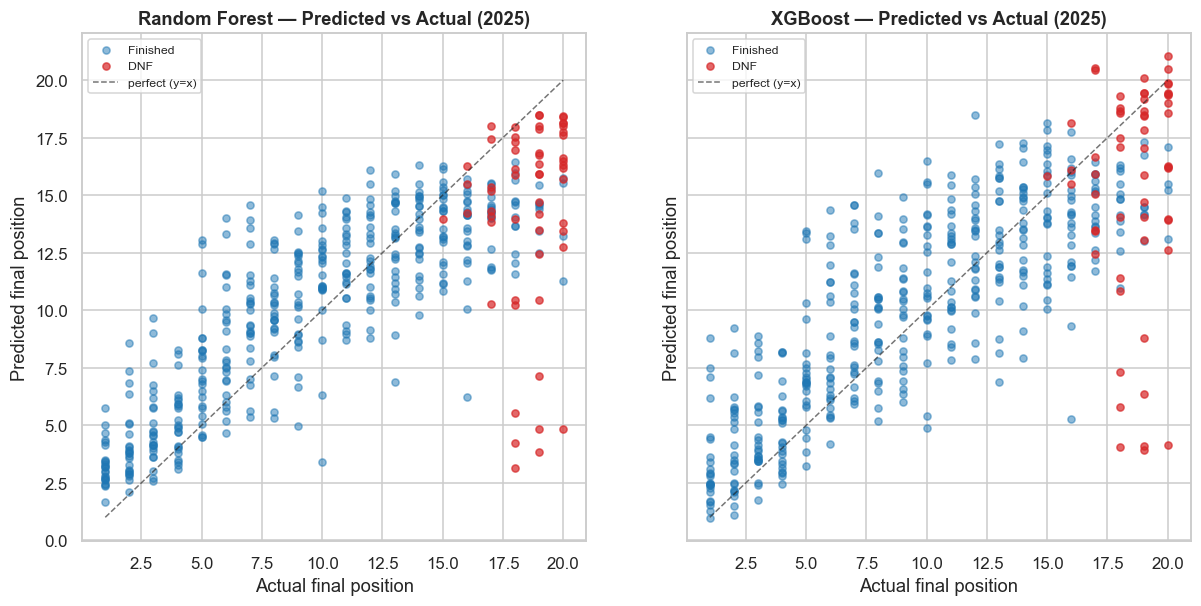

In [41]:
# Plot 1 — Predicted vs Actual (both models), coloured by DNF status.
dnf_mask = test_df["dnf"].astype(bool).values
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, pred, title in [(axes[0], rf_pred, "Random Forest"), (axes[1], xgb_pred, "XGBoost")]:
    ax.scatter(y_test[~dnf_mask], pred[~dnf_mask], s=22, alpha=0.5, color="#1f77b4", label="Finished")
    ax.scatter(y_test[dnf_mask], pred[dnf_mask], s=22, alpha=0.7, color="#d62728", label="DNF")
    ax.plot([1, 20], [1, 20], "k--", lw=1, alpha=0.6, label="perfect (y=x)")
    ax.set_title(f"{title} — Predicted vs Actual (2025)")
    ax.set_xlabel("Actual final position"); ax.set_ylabel("Predicted final position")
    ax.legend(loc="upper left", fontsize=8)
save_fig(fig, "10_predicted_vs_actual.png"); plt.show()

  saved -> reports/figures/11_residual_distribution.png


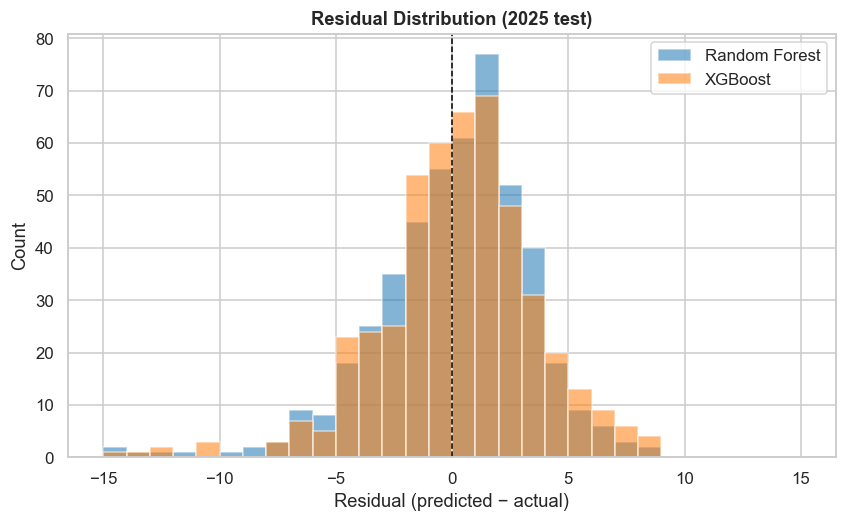

In [42]:
# Plot 2 — Residual distribution (pred - actual), both models.
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(-15, 15.5, 1)
ax.hist(rf_pred - y_test, bins=bins, alpha=0.55, label="Random Forest", color="#1f77b4")
ax.hist(xgb_pred - y_test, bins=bins, alpha=0.55, label="XGBoost", color="#ff7f0e")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Residual (predicted − actual)"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution (2025 test)"); ax.legend()
save_fig(fig, "11_residual_distribution.png"); plt.show()

  saved -> reports/figures/12_mae_by_grid_bucket.png


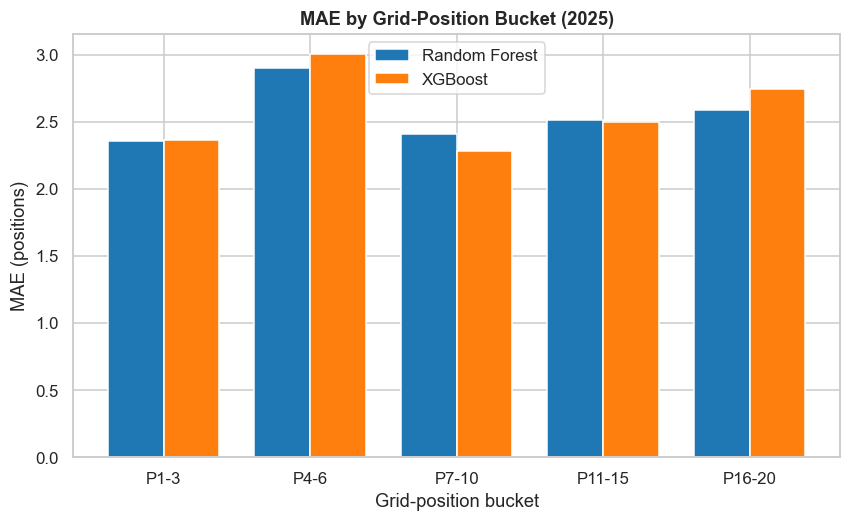

In [43]:
# Plot 3 — MAE by grid-position bucket (where does the model struggle?).
buckets = pd.cut(test_df["grid_position"], bins=[-0.1, 3, 6, 10, 15, 20],
                 labels=["P1-3", "P4-6", "P7-10", "P11-15", "P16-20"])
bdf = pd.DataFrame({"bucket": buckets, "rf_ae": np.abs(rf_pred - y_test),
                    "xgb_ae": np.abs(xgb_pred - y_test)})
bmae = bdf.groupby("bucket", observed=True)[["rf_ae", "xgb_ae"]].mean()
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bmae)); w = 0.38
ax.bar(x - w/2, bmae["rf_ae"], w, label="Random Forest", color="#1f77b4")
ax.bar(x + w/2, bmae["xgb_ae"], w, label="XGBoost", color="#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(bmae.index)
ax.set_xlabel("Grid-position bucket"); ax.set_ylabel("MAE (positions)")
ax.set_title("MAE by Grid-Position Bucket (2025)"); ax.legend()
save_fig(fig, "12_mae_by_grid_bucket.png"); plt.show()

  saved -> reports/figures/13_cv_score_distribution.png


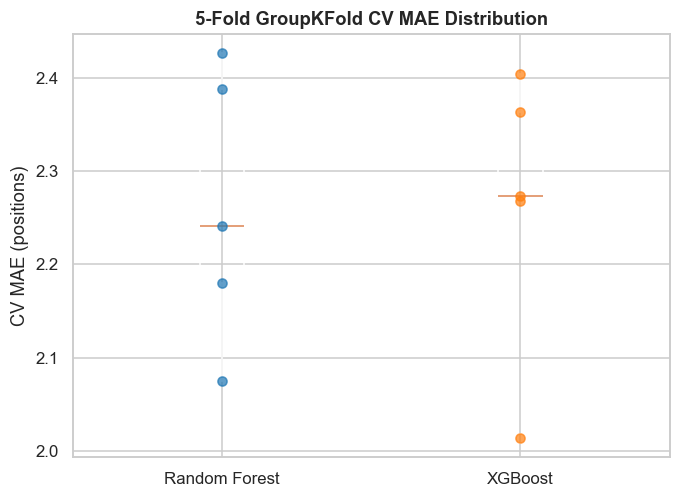

In [44]:
# Plot 4 — CV score distribution (stability).
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rf_cv, xgb_cv], tick_labels=["Random Forest", "XGBoost"])
ax.scatter(np.ones(len(rf_cv)), rf_cv, color="#1f77b4", alpha=0.7, zorder=3)
ax.scatter(np.full(len(xgb_cv), 2), xgb_cv, color="#ff7f0e", alpha=0.7, zorder=3)
ax.set_ylabel("CV MAE (positions)")
ax.set_title("5-Fold GroupKFold CV MAE Distribution")
save_fig(fig, "13_cv_score_distribution.png"); plt.show()

  saved -> reports/figures/14_per_race_mae_2025.png


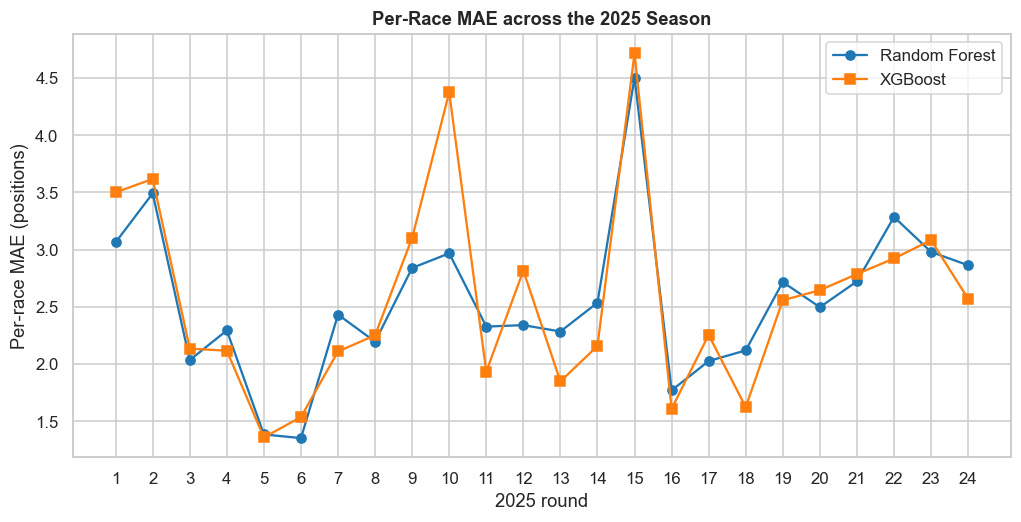

In [45]:
# Plot 5 — Per-race MAE across the 2025 season (degradation over rounds?).
prm = pd.DataFrame({"round": test_df["round"].values,
                    "rf_ae": np.abs(rf_pred - y_test), "xgb_ae": np.abs(xgb_pred - y_test)})
prm = prm.groupby("round")[["rf_ae", "xgb_ae"]].mean().sort_index()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(prm.index, prm["rf_ae"], marker="o", label="Random Forest", color="#1f77b4")
ax.plot(prm.index, prm["xgb_ae"], marker="s", label="XGBoost", color="#ff7f0e")
ax.set_xlabel("2025 round"); ax.set_ylabel("Per-race MAE (positions)")
ax.set_title("Per-Race MAE across the 2025 Season"); ax.legend()
ax.set_xticks(prm.index)
save_fig(fig, "14_per_race_mae_2025.png"); plt.show()

## Robustness Diagnostics
Two honesty checks on the held-out 2025 results — **no retraining, predictions unchanged**:
1. **Finishers-only vs all-drivers error** — DNFs are exogenous retirements the model cannot foresee
   (predicting a specific car's failure would require target-equivalent information). Splitting the
   error by finish status shows the model's true ranking skill vs the ceiling imposed by retirements.
2. **Paired bootstrap 95% CI on test MAE** — a single held-out season carries real sampling variance.
   The CI on the *paired* RF−XGB difference shows whether the model gap is reliable or noise.

In [46]:
# --- Diagnostic 1: finishers-only vs all-drivers error (DNFs are unforeseeable retirements) ---
dnf_mask = test_df["dnf"].astype(bool).values
fin = ~dnf_mask
print(f"2025 test rows: {len(y_test)} | finishers: {fin.sum()} | DNFs: {dnf_mask.sum()} ({dnf_mask.mean():.1%})")
print(f"{'model':14s} {'MAE all':>8s} {'MAE finishers':>14s} {'MAE DNFs':>9s} {'Spearman fin':>13s}")
for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    mae_all = mean_absolute_error(y_test, pred)
    mae_fin = mean_absolute_error(y_test[fin], pred[fin])
    mae_dnf = mean_absolute_error(y_test[dnf_mask], pred[dnf_mask])
    sp_fin = spearmanr(y_test[fin], pred[fin]).correlation
    print(f"{name:14s} {mae_all:8.3f} {mae_fin:14.3f} {mae_dnf:9.3f} {sp_fin:13.3f}")
print("\nFinishers-only MAE is the model's true ranking skill; the all-drivers MAE is inflated by")
print("retirements the model cannot foresee (no per-driver failure feature exists -> that would be target leakage).")

2025 test rows: 476 | finishers: 419 | DNFs: 57 (12.0%)
model           MAE all  MAE finishers  MAE DNFs  Spearman fin
Random Forest     2.545          2.305     4.308         0.841
XGBoost           2.570          2.405     3.778         0.816

Finishers-only MAE is the model's true ranking skill; the all-drivers MAE is inflated by
retirements the model cannot foresee (no per-driver failure feature exists -> that would be target leakage).


RF  test MAE 2.545  95% CI [2.338, 2.751]
XGB test MAE 2.570  95% CI [2.365, 2.788]
Paired (XGB - RF) MAE diff +0.025  95% CI [-0.075, +0.127]
=> 0 lies inside the difference CI: the two models are statistically indistinguishable on 2025.
  saved -> reports/figures/19_bootstrap_mae_ci.png


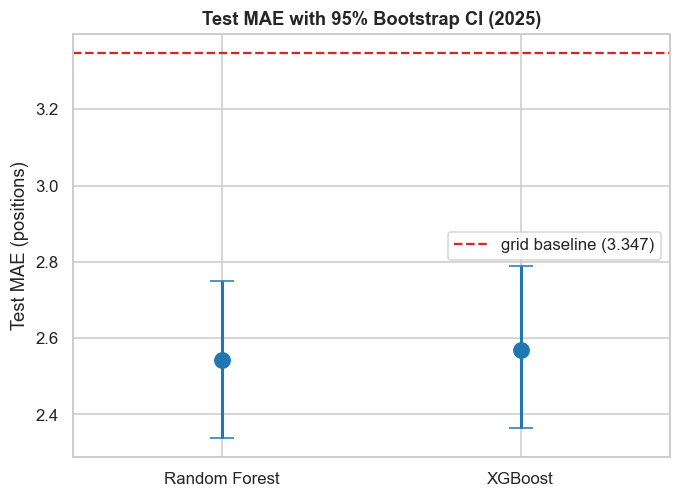

In [47]:
# --- Diagnostic 2: paired bootstrap 95% CI on test MAE (one held-out season has real sampling variance) ---
rng = np.random.default_rng(42)
n, B = len(y_test), 2000
rf_boot = np.empty(B); xgb_boot = np.empty(B)
for b in range(B):
    idx = rng.integers(0, n, n)               # same resample applied to both models (paired)
    yt = y_test[idx]
    rf_boot[b]  = mean_absolute_error(yt, rf_pred[idx])
    xgb_boot[b] = mean_absolute_error(yt, xgb_pred[idx])
ci = lambda a: (a.mean(), np.percentile(a, 2.5), np.percentile(a, 97.5))
rf_mu, rf_lo, rf_hi = ci(rf_boot)
xgb_mu, xgb_lo, xgb_hi = ci(xgb_boot)
d_mu, d_lo, d_hi = ci(xgb_boot - rf_boot)     # paired XGBoost - RF on identical resamples

print(f"RF  test MAE {rf_m['mae']:.3f}  95% CI [{rf_lo:.3f}, {rf_hi:.3f}]")
print(f"XGB test MAE {xgb_m['mae']:.3f}  95% CI [{xgb_lo:.3f}, {xgb_hi:.3f}]")
print(f"Paired (XGB - RF) MAE diff {d_mu:+.3f}  95% CI [{d_lo:+.3f}, {d_hi:+.3f}]")
print("=> 0 lies inside the difference CI: the two models are statistically indistinguishable on 2025."
      if d_lo < 0 < d_hi else "=> difference CI excludes 0: a statistically reliable gap.")

fig, ax = plt.subplots(figsize=(7, 5))
xs = [0, 1]
ax.errorbar(xs, [rf_mu, xgb_mu],
            yerr=[[rf_mu - rf_lo, xgb_mu - xgb_lo], [rf_hi - rf_mu, xgb_hi - xgb_mu]],
            fmt="o", ms=10, lw=2, capsize=8, color="#1f77b4")
ax.axhline(baseline_grid, ls="--", color="#d62728", label=f"grid baseline ({baseline_grid:.3f})")
ax.set_xticks(xs); ax.set_xticklabels(["Random Forest", "XGBoost"])
ax.set_xlim(-0.5, 1.5); ax.set_ylabel("Test MAE (positions)")
ax.set_title("Test MAE with 95% Bootstrap CI (2025)"); ax.legend()
save_fig(fig, "19_bootstrap_mae_ci.png"); plt.show()

## Model Selection
Criteria in order: (1) lower test MAE, (2) higher Spearman r, (3) lower CV std.

In [48]:
def pick(rf_m, xgb_m, rf_cv, xgb_cv):
    if abs(rf_m["mae"] - xgb_m["mae"]) > 1e-6:
        return ("Random Forest", "RF") if rf_m["mae"] < xgb_m["mae"] else ("XGBoost", "XGB")
    if abs(rf_m["spearman"] - xgb_m["spearman"]) > 1e-6:
        return ("Random Forest", "RF") if rf_m["spearman"] > xgb_m["spearman"] else ("XGBoost", "XGB")
    return ("Random Forest", "RF") if rf_cv.std() < xgb_cv.std() else ("XGBoost", "XGB")

selected, tag = pick(rf_m, xgb_m, rf_cv, xgb_cv)
sel_m, sel_cv = (rf_m, rf_cv) if tag == "RF" else (xgb_m, xgb_cv)
reason = (f"lowest test MAE ({sel_m['mae']:.3f}); Spearman r={sel_m['spearman']:.3f}, "
          f"within ±5={sel_m['within_5']:.1%}, CV {sel_cv.mean():.3f}±{sel_cv.std():.3f}")
print("=== MODEL SELECTION ===")
print(f"Selected: {selected}")
print(f"Reason: {reason}")

=== MODEL SELECTION ===
Selected: Random Forest
Reason: lowest test MAE (2.545); Spearman r=0.803, within ±5=91.4%, CV 2.262±0.130


## CP3 Final Summary

In [49]:
def block(name, m, cv):
    return (f"{name}:\n"
            f"  CV MAE    : {cv.mean():.3f} ± {cv.std():.3f}\n"
            f"  Test MAE  : {m['mae']:.3f} positions\n"
            f"  Test R²   : {m['r2']:.3f}\n"
            f"  Spearman r: {m['spearman']:.3f}\n"
            f"  Within ±3 : {m['within_3']:.1%}\n"
            f"  Within ±5 : {m['within_5']:.1%}")

print("=== CP3 COMPLETE ===")
print(block("Random Forest", rf_m, rf_cv))
print(block("XGBoost", xgb_m, xgb_cv))
print(f"\nBaselines:\n  Grid position MAE : {baseline_grid:.3f}\n  Mean prediction MAE: {baseline_mean:.3f}")
print(f"\nSelected model: {selected}")
print(f"Plots saved: {len(saved_figures)} files in reports/figures/")
print("Known issues for CP4:")
print("  - driver_encoded is an arbitrary label code: read its SHAP importance cautiously")
print("    (partly memorisation; the rolling-form features are the generalisable driver signal).")
print("  - 3 rookies (ANT/BOR/HAD) used the median driver code on debut; form features carry them after.")
print("  - 'season'=2025 is an unseen value to the trees (ordinal split-safe).")
print("  - Imputer saved to models/imputer.pkl; constructor_season_points uses a fixed 0-fill (season start).")

=== CP3 COMPLETE ===
Random Forest:
  CV MAE    : 2.262 ± 0.130
  Test MAE  : 2.545 positions
  Test R²   : 0.646
  Spearman r: 0.803
  Within ±3 : 77.5%
  Within ±5 : 91.4%
XGBoost:
  CV MAE    : 2.264 ± 0.136
  Test MAE  : 2.570 positions
  Test R²   : 0.627
  Spearman r: 0.789
  Within ±3 : 73.7%
  Within ±5 : 90.5%

Baselines:
  Grid position MAE : 3.347
  Mean prediction MAE: 4.962

Selected model: Random Forest
Plots saved: 6 files in reports/figures/
Known issues for CP4:
  - driver_encoded is an arbitrary label code: read its SHAP importance cautiously
    (partly memorisation; the rolling-form features are the generalisable driver signal).
  - 3 rookies (ANT/BOR/HAD) used the median driver code on debut; form features carry them after.
  - 'season'=2025 is an unseen value to the trees (ordinal split-safe).
  - Imputer saved to models/imputer.pkl; constructor_season_points uses a fixed 0-fill (season start).
